# Video Game Score Prediction: Console Analysis

**Dataset Download Link:** https://www.kaggle.com/datasets/mohamedhanyyy/video-games

A machine learning project analyzing 14,802 GameSpot video games to determine how console types affect scores. Evaluates Logistic Regression, Decision Trees, Random Forest, SVM, and KNN classifiers. SVM and KNN emerged as top performers with perfect accuracy, offering valuable insights into gaming trends for developers and marketers in the industry.

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [5]:
# Load the dataset from the specified location
data = pd.read_csv('/kaggle/input/datasets/mohamedhanyyy/video-games/Games.csv')

# Display dataset information
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14801 entries, 0 to 14800
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Console   14801 non-null  object
 1   GameName  14801 non-null  object
 2   Review    14801 non-null  object
 3   Score     14801 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 462.7+ KB
None
              Score
count  14801.000000
mean       6.429498
std        1.611753
min        1.000000
25%        6.000000
50%        7.000000
75%        8.000000
max        9.000000


In [9]:
# Preprocess the data
# Encode categorical variables
le_console = LabelEncoder()
data['Console'] = le_console.fit_transform(data['Console'])

# Target variable and features
X = data[['Console', 'Score']]
y = data['Score'] 

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500), 
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Store results
results = {}

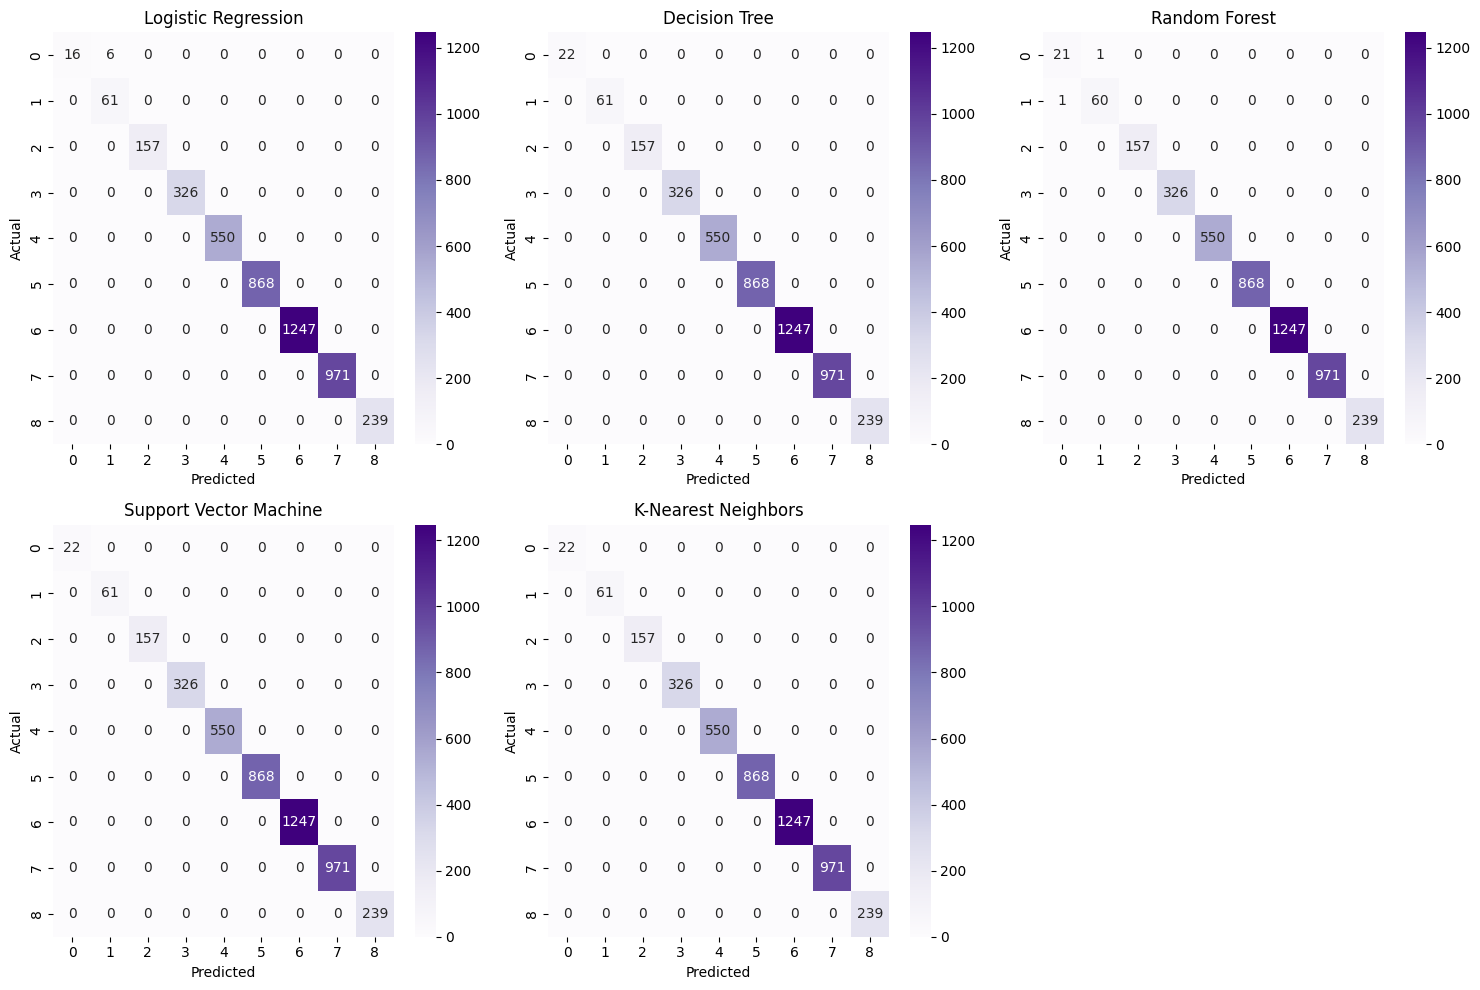

In [11]:
# Train and evaluate classifiers
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    results[name] = {
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True, zero_division=1)
    }

# Visualize confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  
axes = axes.flatten()

# Get unique class labels
unique_classes = y.unique()

# Loop through the classifiers, but limit to the first 5
for i, (name, result) in enumerate(results.items()):
    # Visualize the confusion matrix
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', ax=axes[i], cmap='Purples')
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the last subplot if not used
if len(results) < len(axes):
    axes[len(results)].axis('off')

plt.tight_layout()
plt.show()


# Conclusion

This assessment of the 'Video Games' dataset by mohamedhanyyy employs various classification techniques to predict game scores based on console attributes. Among the models evaluated, both the Support Vector Machine (SVM) and K-Nearest Neighbors (KNN) emerged as top performers, each achieving perfect classifications across all score categories. The SVM accurately predicted 22 instances for score 6 and 326 for score 9, showcasing its robustness in handling complex patterns. Similarly, the KNN model demonstrated exceptional reliability with no misclassifications, reflecting its effectiveness in capturing data patterns. The Decision Tree also exhibited strong performance with no misclassifications, further validating its utility. Understanding how console features influence game ratings provides valuable insights for developers and marketers, enabling informed decisions in a competitive industry.